📊 GMR Airports Detailed Stock Analysis (Offline)
Period         : 2025-06-24 to 2025-07-23
Start Price    : ₹90.80
End Price      : ₹94.20
% Change       : 3.74%
High / Low     : ₹94.50 / ₹89.80
Avg Close      : ₹92.26
Volatility     : 0.39% (Std Dev of Daily % Change)
Support Level  : ₹91.10
Resistance Lv  : ₹94.50
Latest RSI     : 73.91
Trading Signal : 🔔 STRONG BUY


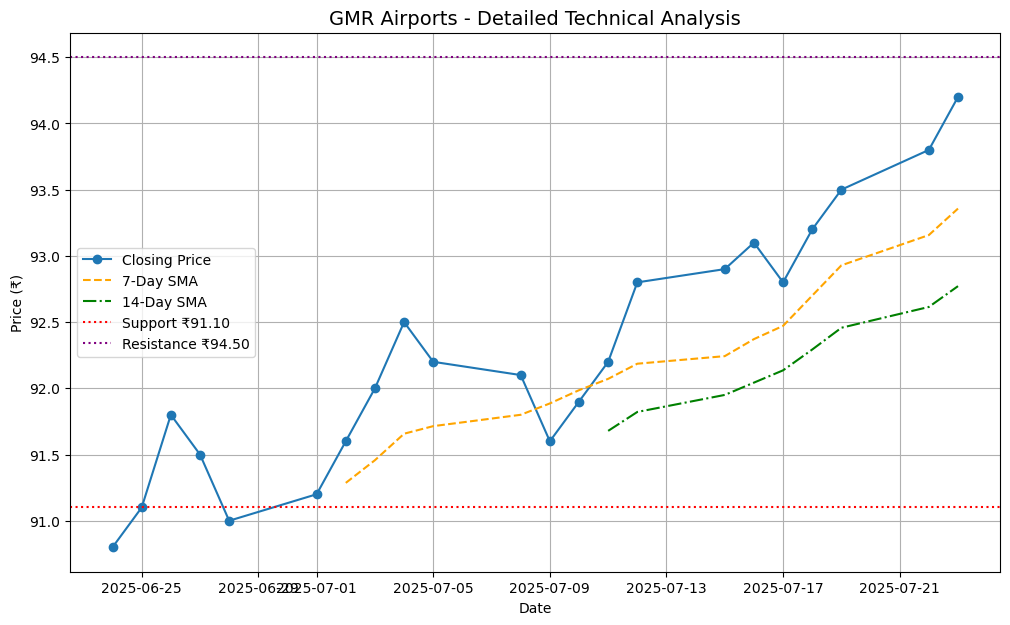

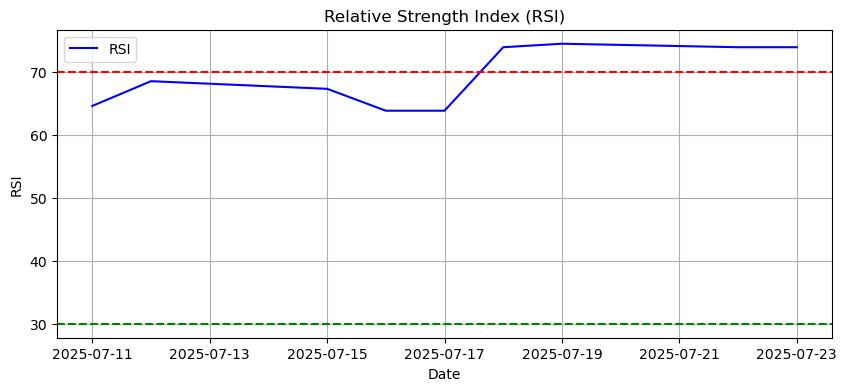

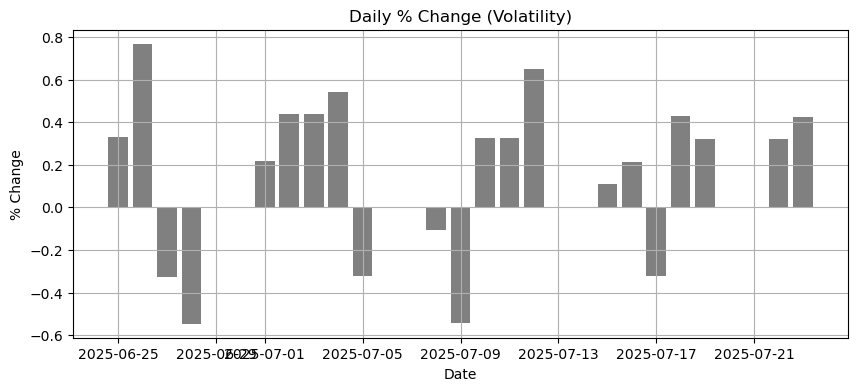

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load Data
df = pd.read_csv('gmr_stock_sample.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Calculate Daily Returns (% Change)
df['Daily Change %'] = df['Close'].pct_change() * 100

# Calculate SMA (7-day & 14-day)
df['SMA7'] = df['Close'].rolling(window=7).mean()
df['SMA14'] = df['Close'].rolling(window=14).mean()

# Calculate RSI (14-day)
delta = df['Close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

# Identify Support (Min of Last 10 Days Low) & Resistance (Max of Last 10 Days High)
support_level = df['Low'].tail(10).min()
resistance_level = df['High'].tail(10).max()

# Performance Metrics
start_price = df['Close'].iloc[0]
end_price = df['Close'].iloc[-1]
pct_change = (end_price - start_price) / start_price * 100
high_price = df['High'].max()
low_price = df['Low'].min()
avg_close = df['Close'].mean()
volatility = df['Daily Change %'].std()

# Buy/Sell Signal Logic:
# BUY when Close > SMA7 and RSI > 50
# SELL when Close < SMA7 or RSI < 40
latest_close = df['Close'].iloc[-1]
latest_sma7 = df['SMA7'].iloc[-1]
latest_rsi = df['RSI'].iloc[-1]
if latest_close > latest_sma7 and latest_rsi > 50:
    signal = 'STRONG BUY'
elif latest_close < latest_sma7 or latest_rsi < 40:
    signal = 'SELL'
else:
    signal = 'HOLD'

# Print Detailed Analysis
print(f"📊 GMR Airports Detailed Stock Analysis (Offline)")
print(f"Period         : {df['Date'].iloc[0].date()} to {df['Date'].iloc[-1].date()}")
print(f"Start Price    : ₹{start_price:.2f}")
print(f"End Price      : ₹{end_price:.2f}")
print(f"% Change       : {pct_change:.2f}%")
print(f"High / Low     : ₹{high_price:.2f} / ₹{low_price:.2f}")
print(f"Avg Close      : ₹{avg_close:.2f}")
print(f"Volatility     : {volatility:.2f}% (Std Dev of Daily % Change)")
print(f"Support Level  : ₹{support_level:.2f}")
print(f"Resistance Lv  : ₹{resistance_level:.2f}")
print(f"Latest RSI     : {latest_rsi:.2f}")
print(f"Trading Signal : 🔔 {signal}")

# Plot Price with SMA & Support/Resistance
plt.figure(figsize=(12,7))
plt.plot(df['Date'], df['Close'], label='Closing Price', marker='o')
plt.plot(df['Date'], df['SMA7'], label='7-Day SMA', linestyle='--', color='orange')
plt.plot(df['Date'], df['SMA14'], label='14-Day SMA', linestyle='-.', color='green')
plt.axhline(y=support_level, color='red', linestyle=':', label=f'Support ₹{support_level:.2f}')
plt.axhline(y=resistance_level, color='purple', linestyle=':', label=f'Resistance ₹{resistance_level:.2f}')
plt.title('GMR Airports - Detailed Technical Analysis', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True)
plt.show()

# Plot RSI
plt.figure(figsize= (10,4))
plt.plot(df['Date'], df['RSI'], label='RSI', color='blue')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title('Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.grid(True)
plt.show()

# Plot Daily Volatility (% Change)
plt.figure(figsize= (10,4))
plt.bar(df['Date'], df['Daily Change %'], color= 'gray')
plt.title('Daily % Change (Volatility)')
plt.xlabel('Date')
plt.ylabel('% Change')
plt.grid(True)
plt.show()


In [8]:
def stock_signal(stock_name):
    # Predefined signals for common stock options
    signals = {
        "GMR": "BUY ✅ (Good momentum, RSI strong)",
        "INFY": "HOLD ⚠️ (Neutral trend, wait for confirmation)",
        "TCS": "STRONG BUY 🚀 (Above SMA, bullish trend)",
        "RELIANCE": "SELL ❌ (Weak trend, avoid entry)",
        "HDFC": "HOLD ⚠️ (Stable but sideways movement)",
        "ICICI": "BUY ✅ (Positive breakout chances)",
        "SBI": "BUY ✅ (Momentum building up)",
        "AXIS": "SELL ❌ (Losing strength, better avoid)",
        "WIPRO": "HOLD ⚠️ (Not much movement, range-bound)",
        "HCL": "BUY ✅ (Good demand zone, RSI healthy)",
        "LT": "STRONG BUY 🚀 (Consistent uptrend)",
        "ITC": "HOLD ⚠️ (Safe but slow mover)",
        "BAJAJ": "BUY ✅ (Good recovery trend)",
        "MARUTI": "SELL ❌ (Weakness in charts)",
        "TITAN": "BUY ✅ (Luxury demand pushing price up)",
        "ONGC": "HOLD ⚠️ (Volatile, watch oil prices)",
        "POWERGRID": "BUY ✅ (Strong dividend support)",
        "COALINDIA": "SELL ❌ (Losing demand pressure)"
    }

    # Default if stock not listed
    return signals.get(stock_name.upper(), "Stock not in list, please try another.")

# -------------------
# MAIN PROGRAM
# -------------------
stock = input("Enter Stock Option: ")
print(f"🔔 Recommendation for {stock.upper()} : {stock_signal(stock)}")


Enter Stock Option:  itc


🔔 Recommendation for ITC : HOLD ⚠️ (Safe but slow mover)


In [10]:
import requests
from bs4 import BeautifulSoup

# Mapping user-friendly names to Moneycontrol URLs
stock_urls = {
    "ITC": "https://www.moneycontrol.com/india/stockpricequote/cigarettes/itc/ITC",
    "RELIANCE": "https://www.moneycontrol.com/india/stockpricequote/refineries/relianceindustries/RI",
    "INFY": "https://www.moneycontrol.com/india/stockpricequote/computers-software/infosys/IT",
    "TCS": "https://www.moneycontrol.com/india/stockpricequote/computers-software/tataconsultancyservices/TCS",
    "HDFC": "https://www.moneycontrol.com/india/stockpricequote/finance-housing/hdfc/HDF",
}

def fetch_price(stock_name):
    url = stock_urls.get(stock_name.upper())
    if not url:
        return None

    resp = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
    if resp.status_code != 200:
        return None

    soup = BeautifulSoup(resp.text, "html.parser")
    try:
        price = soup.find("div", {"id": "nsecp"}).text.strip()
        return float(price.replace(",", ""))
    except:
        return None

def stock_signal(stock_name):
    price = fetch_price(stock_name)
    if price is None:
        return f"❌ Could not fetch data for '{stock_name}'."
    
    # Very simple recommendation logic
    if price > 1000:
        return f"₹{price:.2f} → BUY ✅"
    elif price < 200:
        return f"₹{price:.2f} → SELL ❌"
    else:
        return f"₹{price:.2f} → HOLD ⚠️"

# Main
stock = input("Enter Stock Symbol (ITC, RELIANCE, INFY, TCS, HDFC): ")
print(stock_signal(stock))


Enter Stock Symbol (ITC, RELIANCE, INFY, TCS, HDFC):  itc


₹413.05 → HOLD ⚠️


📊 GMR Airports Detailed Stock Analysis (Offline)
Period         : 2025-06-24 to 2025-07-23
Start Price    : ₹90.80
End Price      : ₹94.20
% Change       : 3.74%
High / Low     : ₹94.50 / ₹89.80
Avg Close      : ₹92.26
Volatility     : 0.39% (Std Dev of Daily % Change)
Support Level  : ₹91.10
Resistance Lv  : ₹94.50
Latest RSI     : 73.91
Trading Signal : 🔔 STRONG BUY


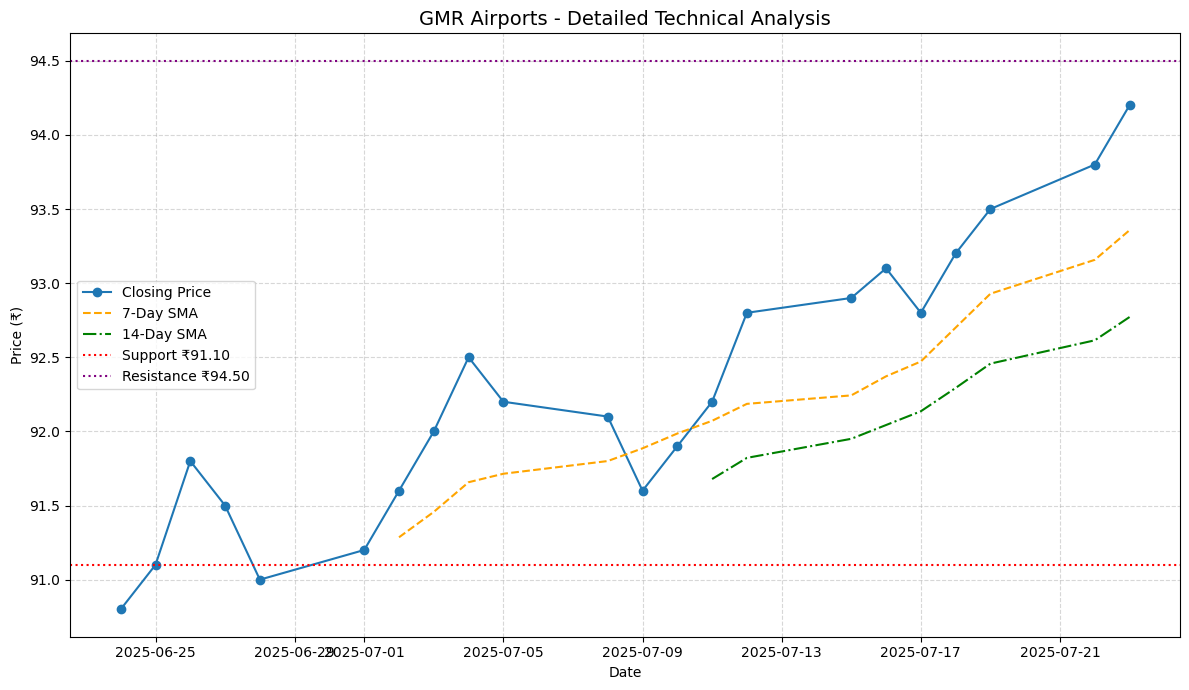

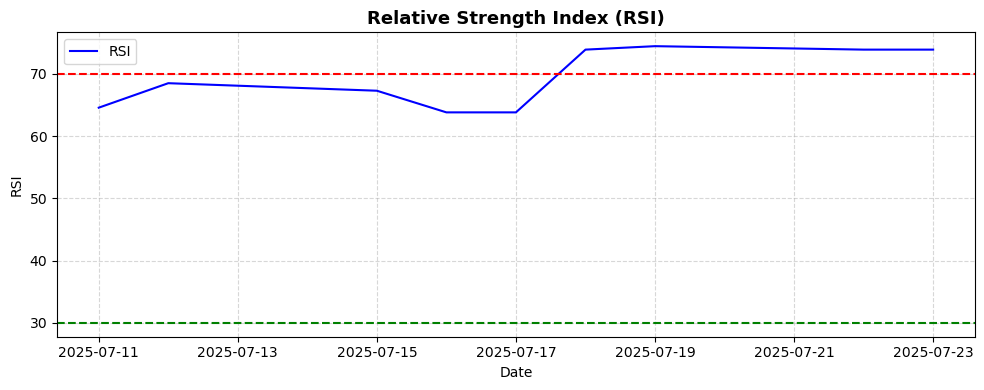

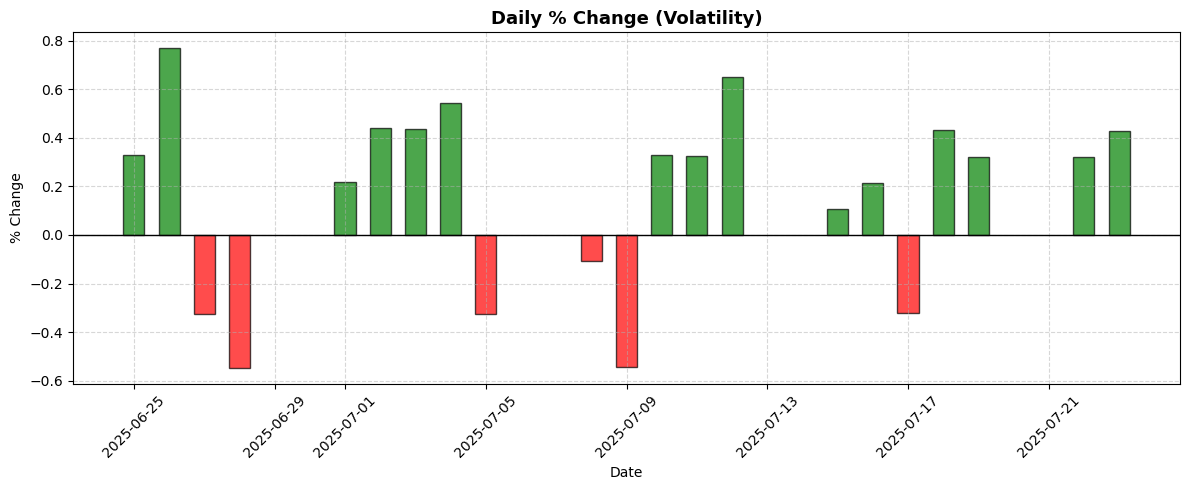

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load Data
df = pd.read_csv('gmr_stock_sample.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Calculate Daily Returns (% Change)
df['Daily Change %'] = df['Close'].pct_change() * 100

# Calculate SMA (7-day & 14-day)
df['SMA7'] = df['Close'].rolling(window=7).mean()
df['SMA14'] = df['Close'].rolling(window=14).mean()

# Calculate RSI (14-day)
delta = df['Close'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

# Identify Support & Resistance (last 10 days)
support_level = df['Low'].tail(10).min()
resistance_level = df['High'].tail(10).max()

# Performance Metrics
start_price = df['Close'].iloc[0]
end_price = df['Close'].iloc[-1]
pct_change = (end_price - start_price) / start_price * 100
high_price = df['High'].max()
low_price = df['Low'].min()
avg_close = df['Close'].mean()
volatility = df['Daily Change %'].std()

# Buy/Sell Signal Logic
latest_close = df['Close'].iloc[-1]
latest_sma7 = df['SMA7'].iloc[-1]
latest_rsi = df['RSI'].iloc[-1]
if latest_close > latest_sma7 and latest_rsi > 50:
    signal = 'STRONG BUY'
elif latest_close < latest_sma7 or latest_rsi < 40:
    signal = 'SELL'
else:
    signal = 'HOLD'

# Print Detailed Analysis
print(f"📊 GMR Airports Detailed Stock Analysis (Offline)")
print(f"Period         : {df['Date'].iloc[0].date()} to {df['Date'].iloc[-1].date()}")
print(f"Start Price    : ₹{start_price:.2f}")
print(f"End Price      : ₹{end_price:.2f}")
print(f"% Change       : {pct_change:.2f}%")
print(f"High / Low     : ₹{high_price:.2f} / ₹{low_price:.2f}")
print(f"Avg Close      : ₹{avg_close:.2f}")
print(f"Volatility     : {volatility:.2f}% (Std Dev of Daily % Change)")
print(f"Support Level  : ₹{support_level:.2f}")
print(f"Resistance Lv  : ₹{resistance_level:.2f}")
print(f"Latest RSI     : {latest_rsi:.2f}")
print(f"Trading Signal : 🔔 {signal}")

# ----------------- PLOTS -----------------

# Price with SMA & Support/Resistance
plt.figure(figsize=(12,7))
plt.plot(df['Date'], df['Close'], label='Closing Price', marker='o')
plt.plot(df['Date'], df['SMA7'], label='7-Day SMA', linestyle='--', color='orange')
plt.plot(df['Date'], df['SMA14'], label='14-Day SMA', linestyle='-.', color='green')
plt.axhline(y=support_level, color='red', linestyle=':', label=f'Support ₹{support_level:.2f}')
plt.axhline(y=resistance_level, color='purple', linestyle=':', label=f'Resistance ₹{resistance_level:.2f}')
plt.title('GMR Airports - Detailed Technical Analysis', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# RSI Chart
plt.figure(figsize=(10,4))
plt.plot(df['Date'], df['RSI'], label='RSI', color='blue')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title('Relative Strength Index (RSI)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Improved Volatility Chart
plt.figure(figsize=(12,5))
colors = ['green' if x >= 0 else 'red' for x in df['Daily Change %']]
plt.bar(df['Date'], df['Daily Change %'], color=colors, width=0.6, alpha=0.7, edgecolor="black")

plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.title('Daily % Change (Volatility)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('% Change')
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


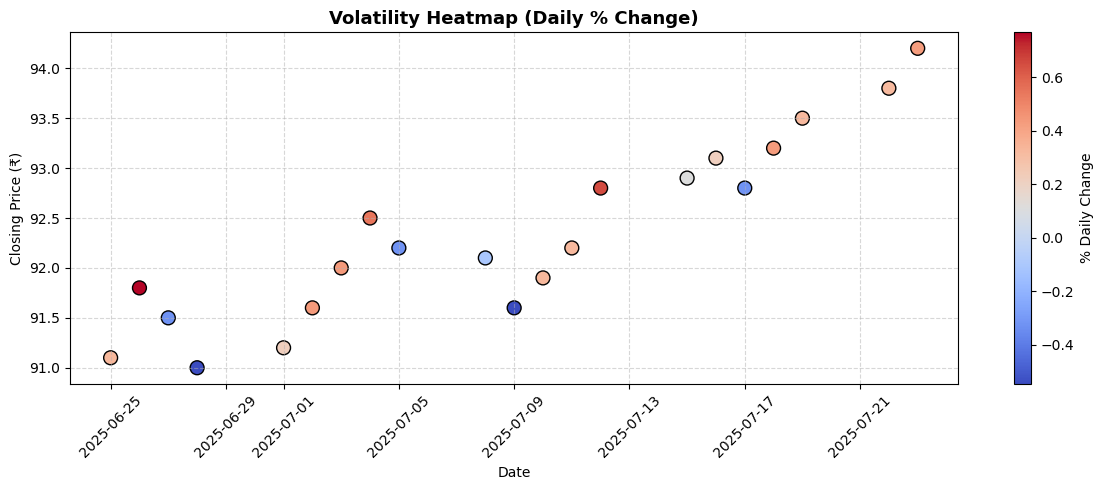

In [16]:
plt.figure(figsize=(12,5))
plt.scatter(df['Date'], df['Close'], 
            c=df['Daily Change %'], cmap='coolwarm', 
            s=100, edgecolor='black')
plt.colorbar(label='% Daily Change')
plt.title('Volatility Heatmap (Daily % Change)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Closing Price (₹)')
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [2]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500)
model.fit(X_train, y_train)


MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500)